# Candidate Test 2022 Analysis Part 2

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2). Consider normalizing the data or performing similar scaling transformations as needed.

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:

- An analysis/description of which questions are most crucial concerning their placement on the axes.
- Average positions of parties concerning each question, preferably with accompanying plots of each (or selected) question.
- A clustering analysis where you attempt various cluster numbers, which would correspond to different parties. Discuss whether there is room for more clusters/parties or if a reduction is needed. Make sure you cover: **K-Means, Hierarchical clustering, and DBSCAN.**
- An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.
- Feel free to explore further and remember that preprocessing, methodology, and evaluation metrics are not mentioned explicitly, but are implicitly assumed.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



In [235]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns

alldata = pd.read_excel("alldata.xlsx")

cols_without_questions = ["navn", "parti", "storkreds", "alder"]
question_cols = [c for c in alldata.columns if c not in cols_without_questions]

y = alldata["parti"]
y = y.dropna()

X = alldata[question_cols]
party_colors = {
    "Alternativet": "#2C903B",
    "Danmarksdemokraterne": "#8CC1FB",
    "Dansk Folkeparti": "#F3C946",
    "Det Konservative Folkeparti": "#9EBA29",
    "Enhedslisten": "#ED8019",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#2C903B",
    "Kristendemokraterne": "#D9D9D9",
    "Liberal Alliance": "#23C3CD",
    "Løsgænger": "#444444",
    "Moderaterne": "#6C38E5",
    "Nye Borgerlige": "#054F5C",
    "Radikale Venstre": "#733581",
    "Socialdemokratiet": "#B32722",
    "Socialistisk Folkeparti": "#DC0778",
    "Venstre": "#006696",
    "Løsgænger": "#555194"
}
#configure the colors to represent the image above.
party_labels = party_colors.keys()

colors = [party_colors.get(p, "#888888") for p in party_labels]



In [236]:
# We dont use train/test/valiadtion split - becouse this is unsupervised learning; we not trying to predict - we try to classify

In [237]:
# Apply PCA to reduce dimensionality
# PCA finds the main axes of variation in the data (political dimensions)

from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X)

print(f"Original shape: {X.shape}")
print(f"PCA shape: {X_pca.shape}")

explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio per PC:", explained_variance)

Original shape: (867, 49)
PCA shape: (867, 49)
Explained variance ratio per PC: [0.45607901 0.11056386 0.05043851 0.0325988  0.02766972 0.02107247
 0.0184712  0.01539926 0.01446637 0.01362734 0.01246812 0.01212725
 0.0113937  0.01054674 0.01004846 0.00959159 0.0093957  0.00883042
 0.0081701  0.00784091 0.00779958 0.00742192 0.00722559 0.00713066
 0.00684986 0.00647814 0.00630544 0.00613937 0.00593062 0.00568824
 0.00543105 0.00517121 0.00510938 0.00492418 0.004825   0.00465238
 0.00445633 0.00440064 0.00393341 0.00388561 0.00373186 0.00349443
 0.0034039  0.00308259 0.00295079 0.00266224 0.00249714 0.00188207
 0.00173684]


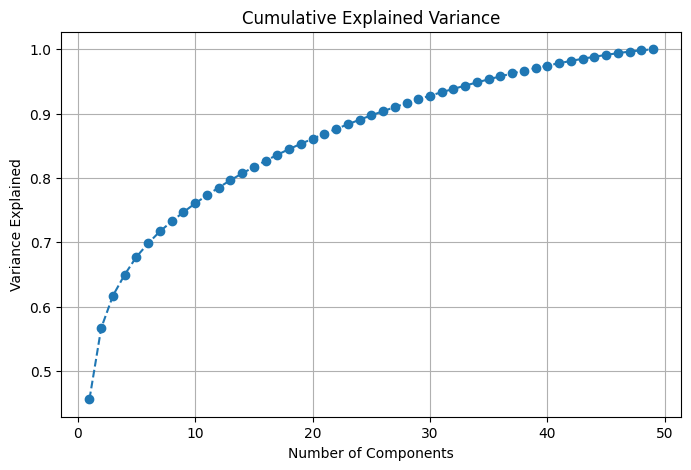

In [238]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid()
plt.show()

In [239]:
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_90}")

Components needed for 90% variance: 26


In [240]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))]
)
pc1_top = loadings["PC1"].abs().sort_values(ascending=False)
pc2_top = loadings["PC2"].abs().sort_values(ascending=False)
top_pc1 = loadings.reindex(pc1_top.index).head(5)
top_pc2 = loadings.reindex(pc2_top.index).head(5)

display("Top PC1 questions:\n", top_pc1)
display("\nTop PC2 questions:\n", top_pc2)

'Top PC1 questions:\n'

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49
531,0.205416,-0.070633,0.034424,0.029472,-0.012094,0.047346,0.219827,-0.039974,0.045868,-0.191414,...,0.150942,-0.199759,0.061745,0.051491,-0.123211,-0.154775,0.078338,0.122970,-0.029659,0.038766
550,0.205066,0.005991,-0.073245,-0.072922,-0.049715,0.178534,-0.024775,0.032639,-0.121543,-0.252342,...,-0.179013,0.124152,-0.171843,-0.244913,0.057590,0.156902,-0.012261,-0.092505,-0.019733,-0.030098
3b,0.204075,0.135642,0.033883,0.081013,0.007262,-0.113744,-0.108776,-0.048256,0.056101,-0.012242,...,-0.185316,0.034019,0.468997,-0.197573,-0.004957,0.170630,-0.360291,0.120037,-0.026530,0.007161
537,-0.198883,0.102179,-0.017608,-0.078153,-0.013152,0.023049,-0.016286,0.179314,0.051697,-0.124878,...,0.116502,-0.228975,-0.058718,0.044295,-0.255255,0.394293,-0.191147,-0.072336,-0.040251,-0.058119
543,-0.193057,-0.002944,-0.141850,-0.009642,-0.078393,0.000088,0.060424,-0.084328,0.062776,-0.129944,...,0.072795,-0.056252,-0.260750,-0.154901,0.021737,-0.153563,-0.066314,-0.003186,-0.038618,0.065063


'\nTop PC2 questions:\n'

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49
556,-0.133250,0.356049,-0.081586,-0.009276,0.082747,-0.227909,0.208346,-0.086085,0.052713,-0.113791,...,-0.057268,-0.062368,-0.018436,-0.005948,0.017696,0.043266,-0.019605,-0.135905,0.608421,-0.260279
10b,0.128328,-0.355004,0.078435,-0.004371,-0.080396,0.235354,-0.179732,0.055898,-0.052476,0.056470,...,0.040397,-0.043678,-0.033294,-0.008211,-0.010085,-0.002267,-0.001823,-0.068197,0.633112,-0.309135
551,-0.116240,-0.298896,0.067716,0.120752,-0.098375,0.135314,-0.069289,-0.206473,-0.228740,-0.075326,...,-0.213680,-0.024371,0.017669,0.152498,0.031999,0.099651,-0.269800,0.086709,0.059771,-0.030668
553,-0.016978,-0.249885,-0.025809,0.249041,-0.097609,-0.346597,-0.068601,-0.070374,0.336013,0.003408,...,0.031129,0.040520,-0.015713,-0.033694,-0.012807,-0.026131,-0.045486,0.053457,0.022150,-0.033023
555,-0.189554,-0.243982,-0.150314,-0.127666,-0.018116,0.065006,0.189717,-0.056383,-0.107028,0.066929,...,-0.086066,0.173865,-0.018479,-0.009813,-0.031646,-0.020869,0.125327,0.059074,-0.323348,-0.615293


In [241]:
rows = []

for pc in ["PC1", "PC2"]:

    top_features = loadings[pc].abs().sort_values(ascending=False).head(5).index

    for rank, feature in enumerate(top_features, start=1):

        q_num = str(feature).replace("DR", "").replace("TV2", "").replace("_", "")

        rows.append({
            "PC": pc,
            "Rank": rank,
            "Question": q_num,
            "Weight": loadings.loc[feature, pc]
        })

result = pd.DataFrame(rows)

display(result)

,PC,Rank,Question,Weight
0,PC1,1,531,0.205416
1,PC1,2,550,0.205066
2,PC1,3,3b,0.204075
3,PC1,4,537,-0.198883
4,PC1,5,543,-0.193057
5,PC2,1,556,0.356049
6,PC2,2,10b,-0.355004
7,PC2,3,551,-0.298896
8,PC2,4,553,-0.249885
9,PC2,5,555,-0.243982


In [242]:
# Put PC1 and PC2 into a DataFrame
pc_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "party": y
})

# Average PC1 and PC2 per party
party_pc_avg = pc_df.groupby("party").mean()

display(party_pc_avg)

,PC1,PC2
party,,
Alternativet,7.057642,1.697298
Danmarksdemokraterne,-5.639608,-5.430754
Dansk Folkeparti,-4.994730,-4.785465
Det Konservative Folkeparti,-6.479327,1.205848
Enhedslisten,9.631156,-1.262511
"Frie Grønne, Danmarks Nye Venstrefløjsparti",8.906763,0.843119
Kristendemokraterne,0.231551,3.773637
Liberal Alliance,-7.629389,3.902370
Løsgænger,-1.842855,0.392431


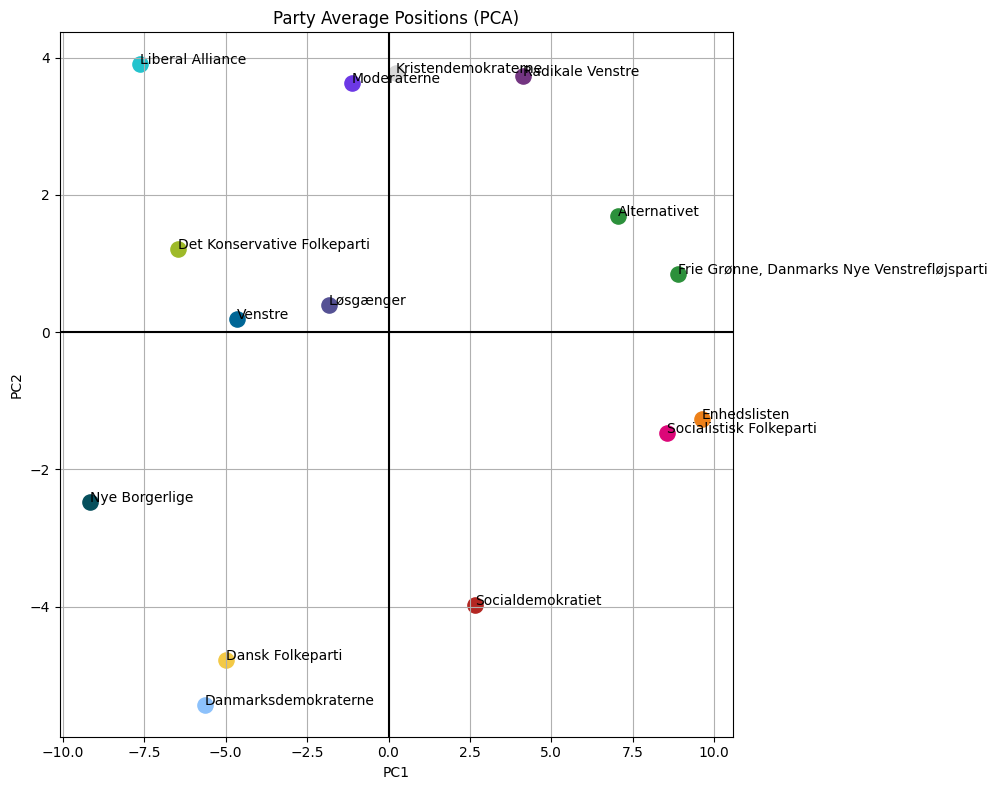

In [243]:
#Average positions of parties concerning each question, preferably with accompanying plots of each (or selected) question.

party_mean = pc_df.groupby("party").mean()

# Plot
plt.figure(figsize=(10, 8))

for party in party_mean.index:
    x = party_mean.loc[party, "PC1"]
    y = party_mean.loc[party, "PC2"]

    plt.scatter(
        x, y,
        color=party_colors.get(party, "black"),
        s=120
    )

    plt.text(x, y, party)

# Axes
plt.axhline(0, color="black")
plt.axvline(0, color="black")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Party Average Positions (PCA)")

plt.grid(True)
plt.tight_layout()
plt.show()

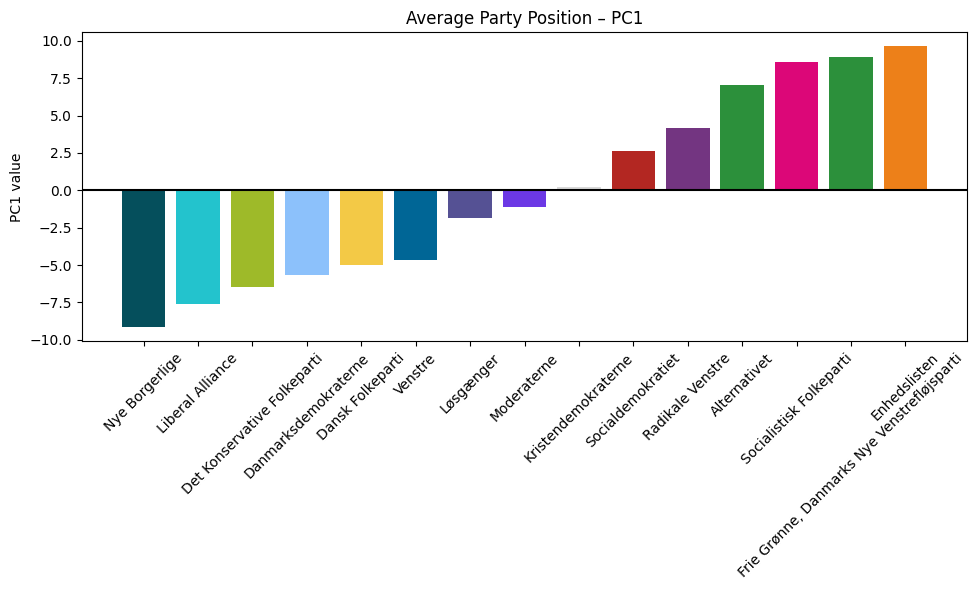

In [244]:
pc1_data = party_mean["PC1"].sort_values()

plt.figure(figsize=(10, 6))

plt.bar(
    pc1_data.index,
    pc1_data.values,
    color=[party_colors.get(p, "black") for p in pc1_data.index]
)

plt.axhline(0, color="black")
plt.xticks(rotation=45)
plt.title("Average Party Position – PC1")
plt.ylabel("PC1 value")

plt.tight_layout()
plt.show()

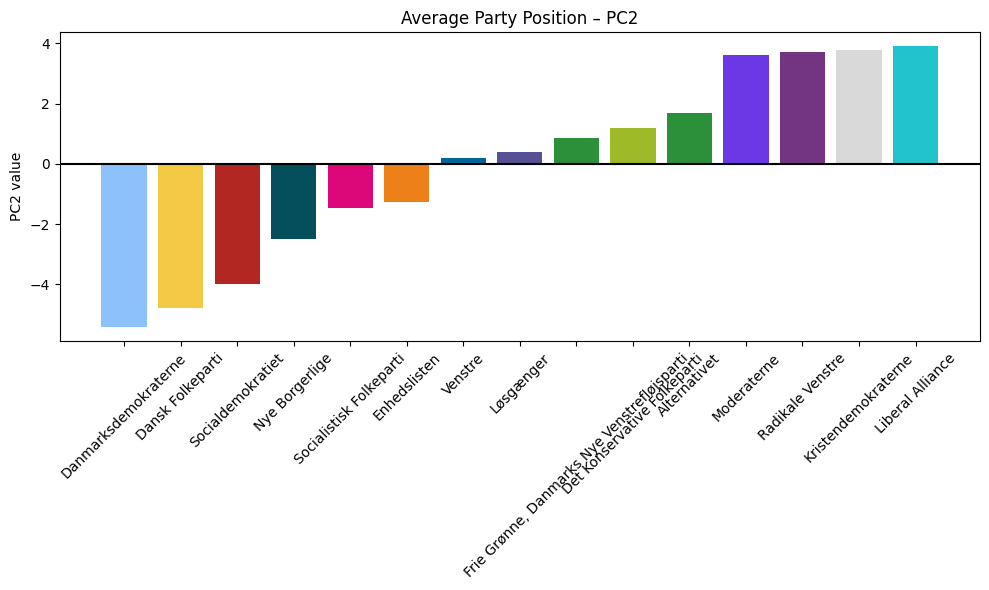

In [245]:
pc2_data = party_mean["PC2"].sort_values()

plt.figure(figsize=(10, 6))

plt.bar(
    pc2_data.index,
    pc2_data.values,
    color=[party_colors.get(p, "black") for p in pc2_data.index]
)

plt.axhline(0, color="black")
plt.xticks(rotation=45)
plt.title("Average Party Position – PC2")
plt.ylabel("PC2 value")

plt.tight_layout()
plt.show()

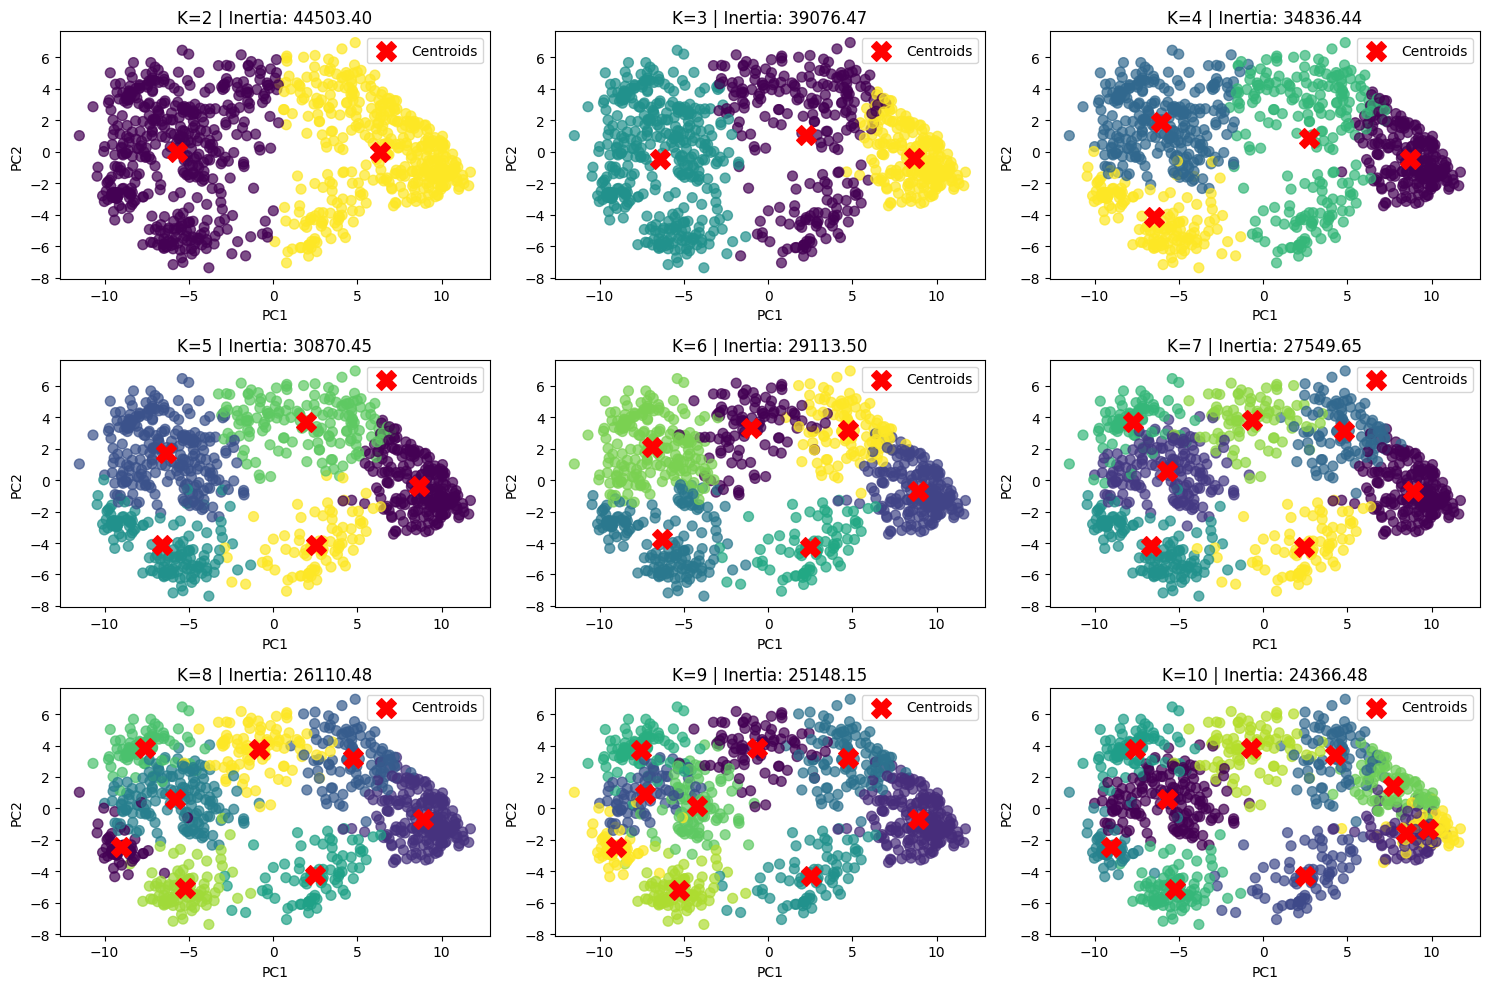

In [246]:
#K-means clustering
# Below is visualisation of different number of cluster would look like (from 2 to 10)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#We decided to use only 26 components, to reduce dimensionality (but still have 90% data)
pca_26 = PCA(n_components=26)
X_pca_26 = pca_26.fit_transform(X)

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]
inertias = []

plt.figure(figsize=(15, 10))

for i, k in enumerate(k_values):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=42
    )

    kmeans.fit(X_pca_26)
    inertias.append(kmeans.inertia_)

    plt.subplot(3, 3, i + 1)

    plt.scatter(
        X_pca_26[:, 0],
        X_pca_26[:, 1],
        c=kmeans.labels_,
        cmap="viridis",
        s=50,
        alpha=0.7
    )

    plt.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        marker="X",
        s=200,
        c="red",
        label="Centroids"
    )

    plt.title(f"K={k} | Inertia: {kmeans.inertia_:.2f}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()

plt.tight_layout()
plt.show()

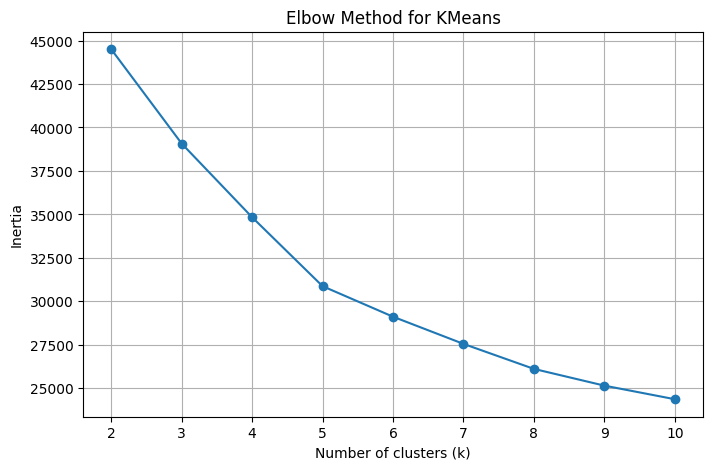

In [247]:
#Elobw Method

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.grid(True)
plt.show()

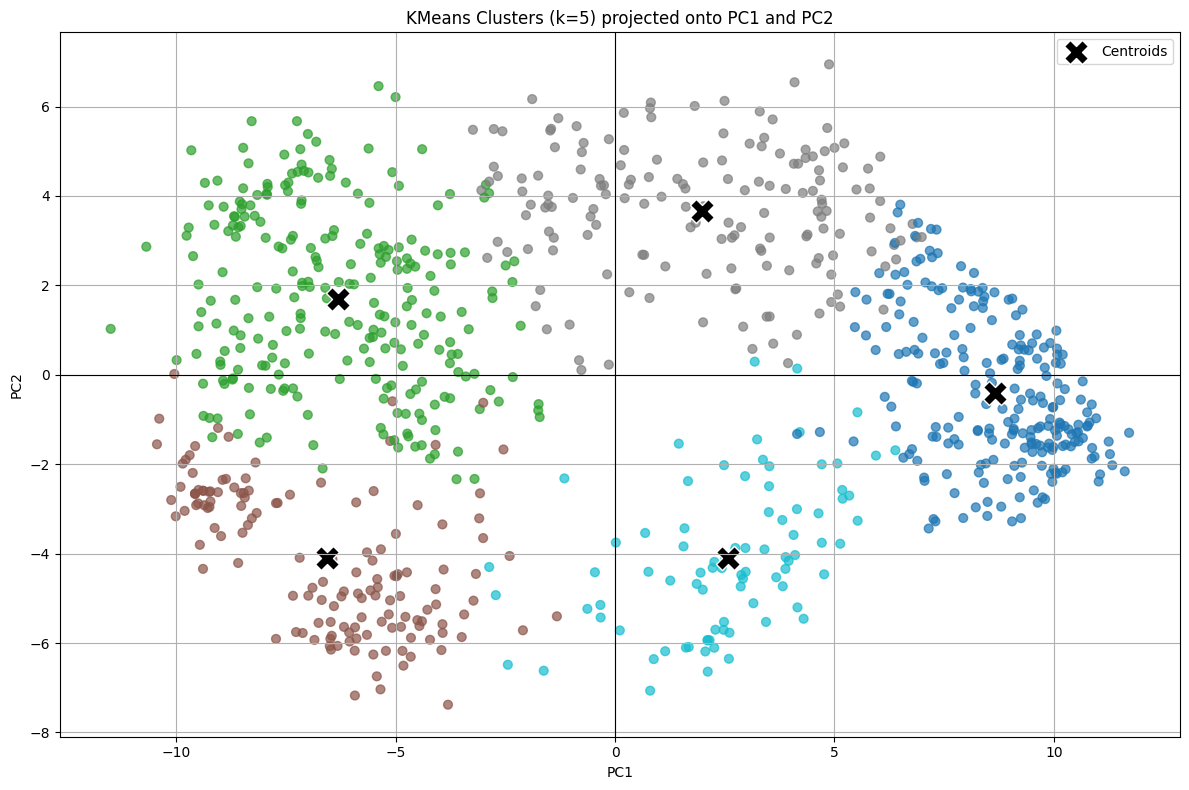

In [248]:
#K means with 5 clusters

km = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42
)

km.fit(X_pca_26)

centroids_pca = km.cluster_centers_

plt.figure(figsize=(12, 8))

plt.scatter(
    X_pca_26[:, 0],
    X_pca_26[:, 1],
    c=km.labels_,
    cmap="tab10",
    alpha=0.7,
    s=40
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=300,
    c="black",
    marker="X",
    edgecolors="white",
    label="Centroids"
)

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters (k=5) projected onto PC1 and PC2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

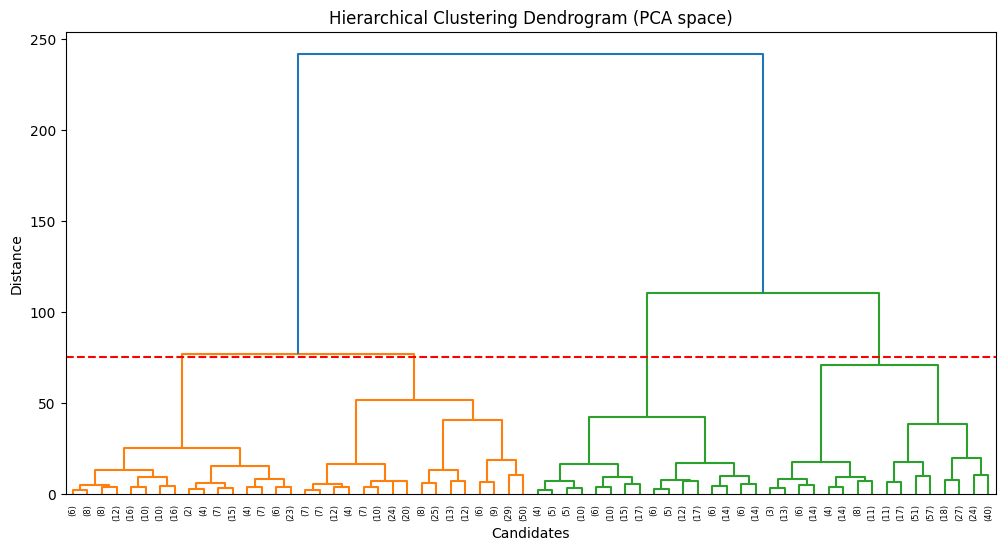

In [249]:
#Hierarchical clustering
#Dendrogram

X_hc = X_pca_26[:, :2]  # use PC1 and PC2

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Ward linkage
Z = linkage(X_hc, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # cleaner visualization
plt.title("Hierarchical Clustering Dendrogram (PCA space)")
plt.xlabel("Candidates")
plt.ylabel("Distance")

# cut line
plt.axhline(75, color='red', linestyle='--')

plt.show()

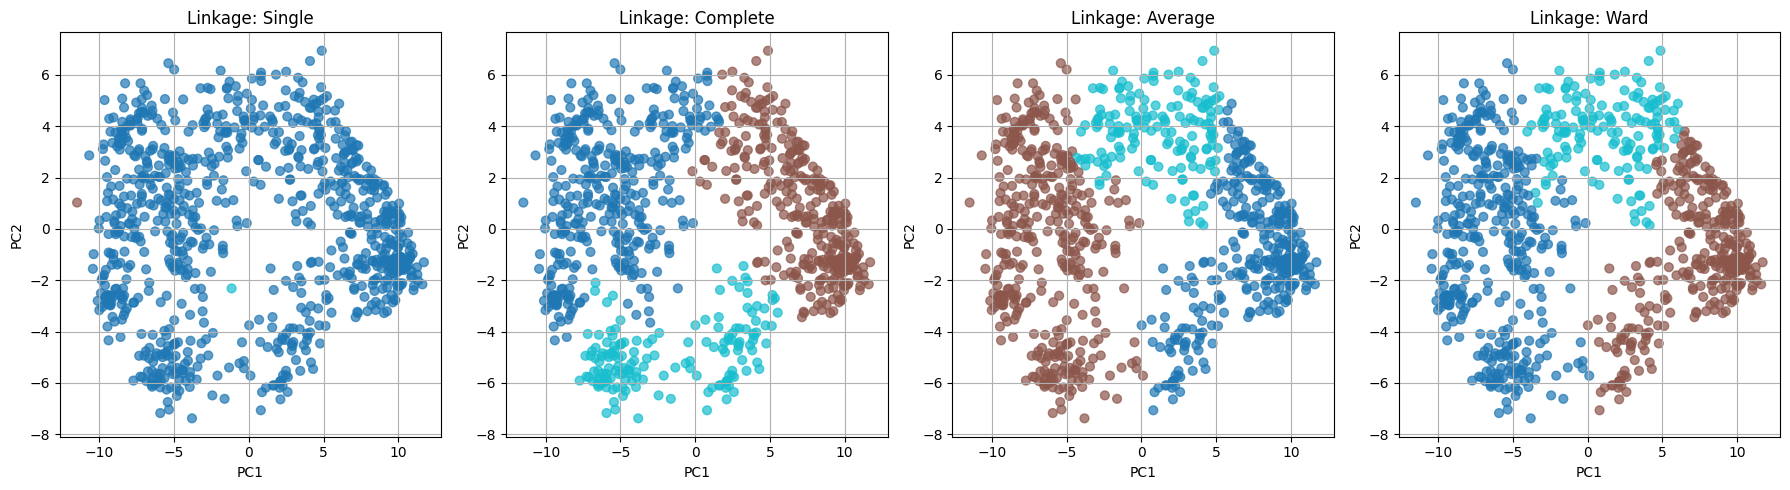

In [250]:
#How different lingeages would look like

X_hc = X_pca_26[:, :2]  # PC1 and PC2

from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

methods = ['single', 'complete', 'average', 'ward']

plt.figure(figsize=(18, 5))

for i, link in enumerate(methods):
    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=link
    )

    labels = model.fit_predict(X_hc)

    plt.subplot(1, 4, i + 1)
    plt.scatter(
        X_hc[:, 0],
        X_hc[:, 1],
        c=labels,
        cmap='tab10',
        s=40,
        alpha=0.7
    )

    plt.title(f"Linkage: {link.capitalize()}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)

plt.tight_layout()
plt.show()

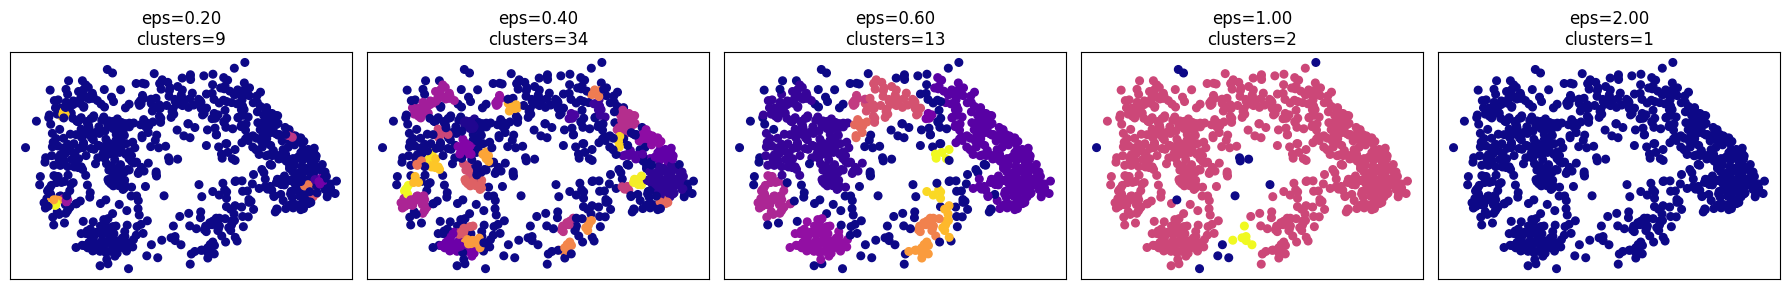

In [251]:
#DBSCAN

from sklearn.cluster import DBSCAN

e_list = [0.2, 0.4, 0.6, 1.0, 2.0]

# Use higher dimensions for clustering
X_db = X_pca_26[:, :2]

plt.figure(figsize=(18, 3))

for i, e in enumerate(e_list):
    res = DBSCAN(eps=e, min_samples=5).fit_predict(X_db)

    n_clusters = len(set(res)) - (1 if -1 in res else 0)

    plt.subplot(1, len(e_list), i+1)

    # Plot only first 2 PCA dims
    plt.scatter(
        X_pca_26[:, 0],
        X_pca_26[:, 1],
        c=res,
        cmap='plasma',
        s=30
    )

    plt.title(f"eps={e:.2f}\nclusters={n_clusters}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

Clusters: 5
Noise: 116


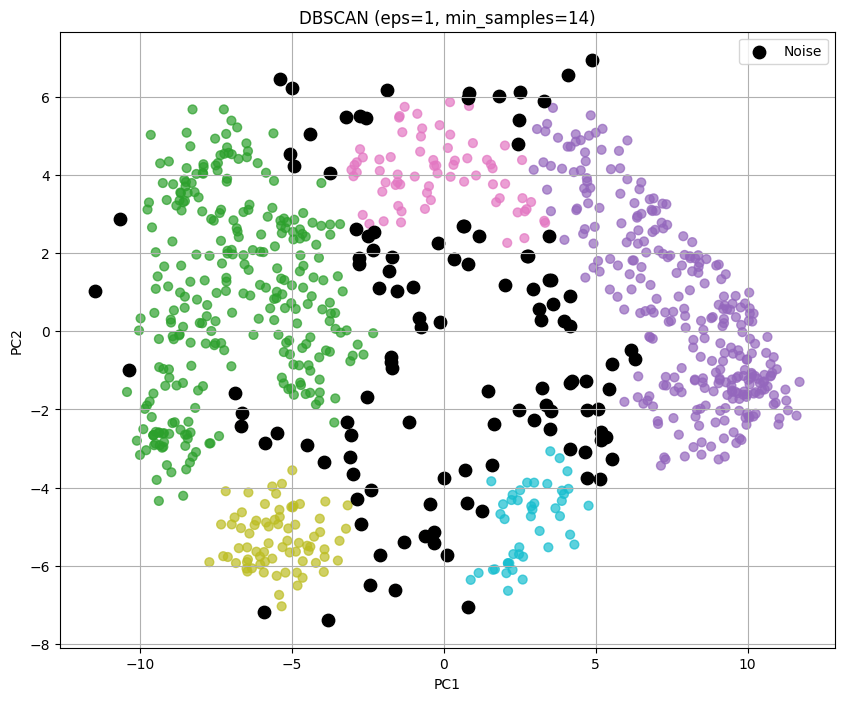

In [252]:
# DBSCAN
db = DBSCAN(
    eps=1,
    min_samples=14
)

labels = db.fit_predict(X_db)

# Stats
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Clusters:", n_clusters)
print("Noise:", n_noise)

# Plot clusters
plt.figure(figsize=(10, 8))

plt.scatter(
    X_db[:, 0],
    X_db[:, 1],
    c=labels,
    cmap="tab10",
    s=40,
    alpha=0.7
)

# Highlight noise
plt.scatter(
    X_db[labels == -1, 0],
    X_db[labels == -1, 1],
    c="black",
    s=80,
    label="Noise"
)

plt.title(f"DBSCAN (eps={1}, min_samples=14)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

In [253]:
# An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.

from sklearn.metrics import pairwise_distances

# Load elected candidates
elected = pd.read_excel("electeddata.xlsx")

# Same question columns as before
X_elected = elected[question_cols]
y_elected = elected["parti"]

# Transform elected candidates using the PCA model already fitted on X
X_elected_pca = pca.transform(X_elected)

elected_pc_df = pd.DataFrame({
    "PC1": X_elected_pca[:, 0],
    "PC2": X_elected_pca[:, 1],
    "navn": elected["navn"],
    "parti": elected["parti"]
})

elected_pc_df.head()

,PC1,PC2,navn,parti
0,9.273625,-1.964813,Karsten Hønge,Socialistisk Folkeparti
1,9.696126,-0.486754,Torsten Gejl,Alternativet
2,10.149315,-1.104211,Mai Villadsen,Enhedslisten
3,-4.844721,-6.174884,Hans Kristian Skibby,Danmarksdemokraterne
4,-4.498955,-2.915193,Troels Lund Poulsen,Venstre


In [254]:
# Use PCA space for distances
dist_matrix = pairwise_distances(elected_pc_df[["PC1", "PC2"]])

dist_df = pd.DataFrame(
    dist_matrix,
    index=elected_pc_df["navn"],
    columns=elected_pc_df["navn"]
)

# Most different candidates
# Candidates who disagree the most (largest distance)
most_different = dist_df.stack().sort_values(ascending=False)

# remove duplicate pairs
most_different = most_different[
    most_different.index.get_level_values(0) != most_different.index.get_level_values(1)
]

most_different.head(10)

navn                      navn                    
Sandra Elisabeth Skalvig  Peder Hvelplund             21.597218
Peder Hvelplund           Sandra Elisabeth Skalvig    21.597218
                          Steffen Larsen              21.498938
Steffen Larsen            Peder Hvelplund             21.498938
Ole Birk Olesen           Peder Hvelplund             20.942086
Peder Hvelplund           Ole Birk Olesen             20.942086
Steffen Frølund           Peder Hvelplund             20.929012
Peder Hvelplund           Steffen Frølund             20.929012
Rosa Lund                 Sandra Elisabeth Skalvig    20.888662
Sandra Elisabeth Skalvig  Rosa Lund                   20.888662
dtype: float64

In [255]:
# Candidates who agree the most (smallest distance)
most_similar = dist_df.replace(0, np.nan).stack().sort_values()
most_similar.head(10)

navn                       navn                     
Lea Wermelin               Rasmus Stoklund              0.047733
Rasmus Stoklund            Lea Wermelin                 0.047733
Hans Andersen              Peter Juel-Jensen            0.066687
Peter Juel-Jensen          Hans Andersen                0.066687
Lise Bech                  Betina Kastbjerg             0.074679
Betina Kastbjerg           Lise Bech                    0.074679
Brigitte Klintskov Jerkel  Søren Pape Poulsen           0.082254
Søren Pape Poulsen         Brigitte Klintskov Jerkel    0.082254
Magnus Johannes Heunicke   Jesper Petersen              0.092288
Jesper Petersen            Magnus Johannes Heunicke     0.092288
dtype: float64

In [256]:
# Measure internal disagreement within each party
# Standard deviation = how spread out party members are

party_spread = elected_pc_df.groupby("parti")[["PC1", "PC2"]].std()

party_spread["total_spread"] = party_spread["PC1"] + party_spread["PC2"]

party_spread.sort_values("total_spread", ascending=False)

,PC1,PC2,total_spread
parti,,,
Socialdemokratiet,2.245090,1.513288,3.758378
Moderaterne,2.419579,1.175335,3.594915
Det Konservative Folkeparti,1.831742,1.404262,3.236004
Alternativet,1.322638,1.510430,2.833068
Venstre,1.114785,1.705216,2.820001
Liberal Alliance,1.240936,1.303146,2.544082
Socialistisk Folkeparti,1.140387,1.162047,2.302434
Danmarksdemokraterne,1.124531,0.852527,1.977058
Dansk Folkeparti,0.996840,0.897235,1.894074
